# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [2]:
! git clone https://github.com/asomers205/scratchpad
%run ./scratchpad/get_data.py

Cloning into 'scratchpad'...
remote: Enumerating objects: 118, done.
remote: Counting objects: 100% (53/53), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 118 (delta 42), reused 31 (delta 30), pack-reused 65 (from 2)
Receiving objects: 100% (118/118), 1.76 MiB | 26.43 MiB/s, done.
Resolving deltas: 100% (55/55), done.
Download complete
Extracting data files...
Data extracted


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score

df = pd.read_csv('data (1).csv', sep=';')

cols = ['Debtor', 'Tuition fees up to date', 'Scholarship holder',
        'Age at enrollment', 'Curricular units 1st sem (approved)', 'Target']
df = df[cols]

print(df.isna().sum())   # check missingness
df = df.dropna()         # none expected in this dataset, but safe

# Binary target: 1 = dropout, 0 = not dropout
df['dropout'] = (df['Target'] == 'Dropout').astype(int)

Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dtype: int64


In [11]:
X = df[['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']]
y = df['dropout']

logit = LogisticRegression(max_iter=1000)
logit.fit(X, y)

coef_df = pd.DataFrame({'var': X.columns, 'coef': logit.coef_[0]})
print(coef_df)
print('intercept:', logit.intercept_[0])

                       var      coef
0                   Debtor  0.530625
1  Tuition fees up to date -2.556542
2       Scholarship holder -1.227442
3        Age at enrollment  0.049925
intercept: 0.4856926578796168


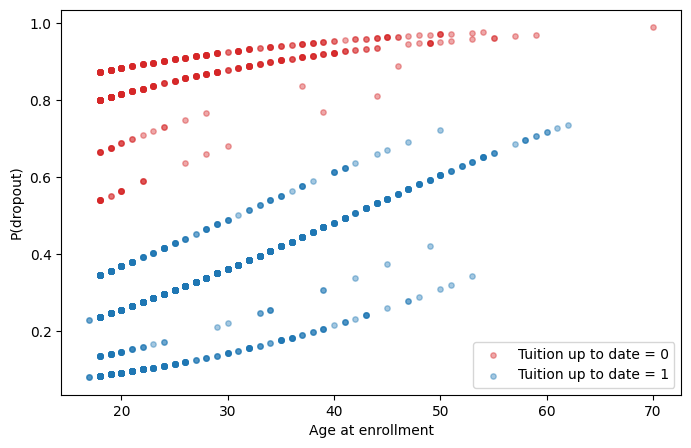

Average change in P(dropout) from being up to date: -0.5161819741831828


In [12]:
probs = logit.predict_proba(X)[:, 1]   # P(dropout)

plt.figure(figsize=(8, 5))
for v, color in [(0, 'tab:red'), (1, 'tab:blue')]:
    mask = X['Tuition fees up to date'] == v
    plt.scatter(X.loc[mask, 'Age at enrollment'], probs[mask],
                alpha=0.4, s=15, c=color, label=f'Tuition up to date = {v}')
plt.xlabel('Age at enrollment'); plt.ylabel('P(dropout)')
plt.legend(); plt.show()

# Average effect: compare counterfactual predictions
X0, X1 = X.copy(), X.copy()
X0['Tuition fees up to date'] = 0
X1['Tuition fees up to date'] = 1
diff = logit.predict_proba(X1)[:, 1] - logit.predict_proba(X0)[:, 1]
print('Average change in P(dropout) from being up to date:', diff.mean())

In [13]:
preds = logit.predict(X)
cm = confusion_matrix(y, preds)
print(cm)
print('Accuracy:', accuracy_score(y, preds))

[[2841  162]
 [ 891  530]]
Accuracy: 0.7619801084990958


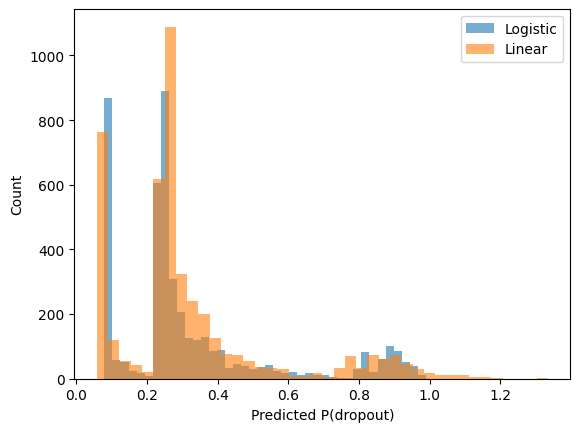

LPM min/max: 0.05832035022573856 1.3349535706758708


In [14]:
lpm = LinearRegression().fit(X, y)
lpm_probs = lpm.predict(X)

plt.hist(probs, bins=40, alpha=0.6, label='Logistic')
plt.hist(lpm_probs, bins=40, alpha=0.6, label='Linear')
plt.xlabel('Predicted P(dropout)'); plt.ylabel('Count')
plt.legend(); plt.show()

print('LPM min/max:', lpm_probs.min(), lpm_probs.max())

#6

the students most at risk of dropping out are ones who are in debt with tuition, do not have a scholarship and are oldering during enrollment.

some potential interventions include tuition assistance/aid. expanding need-based scholarships/aid.

In [15]:
X2 = df[['Debtor', 'Tuition fees up to date', 'Curricular units 1st sem (approved)']]
y2 = df['Target']

mlogit = LogisticRegression(multi_class='multinomial', max_iter=1000)
mlogit.fit(X2, y2)

hard = mlogit.predict(X2)
print('Classes:', mlogit.classes_)
print(confusion_matrix(y2, hard, labels=mlogit.classes_))
print('Accuracy:', accuracy_score(y2, hard))

soft = mlogit.predict_proba(X2)
print(pd.DataFrame(soft, columns=mlogit.classes_).describe())

# Does hard classification ever predict "Enrolled"?
print('Unique hard predictions:', np.unique(hard))

# Does any row have Enrolled as its argmax probability?
print('Max prob for Enrolled across all rows:', soft[:, list(mlogit.classes_).index('Enrolled')].max())

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Classes: ['Dropout' 'Enrolled' 'Graduate']
[[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]
Accuracy: 0.7045660036166366
            Dropout     Enrolled     Graduate
count  4.424000e+03  4424.000000  4424.000000
mean   3.212229e-01     0.179474     0.499303
std    2.866920e-01     0.066308     0.287579
min    9.564711e-07     0.000279     0.002135
25%    1.178080e-01     0.140644     0.172735
50%    1.842268e-01     0.176983     0.603104
75%    5.898657e-01     0.212669     0.705209
max    9.601568e-01     0.327752     0.999720
Unique hard predictions: ['Dropout' 'Graduate']
Max prob for Enrolled across all rows: 0.32775228645763954


**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score

df = pd.read_csv('cirrhosis.csv')
print(df.head())

cols = ['Status', 'Drug', 'Edema', 'Bilirubin', 'Stage']
df = df[cols]

print(df.isna().sum())
df = df.dropna()
print('Rows after dropping NA:', len(df))

# Binary survival target: 1 = alive (C, CL), 0 = dead (D)
df['alive'] = df['Status'].isin(['C', 'CL']).astype(int)

# Encode categoricals for regression
df['drug_pen'] = (df['Drug'] == 'D-penicillamine').astype(int)   # 1 = drug, 0 = placebo
# Edema: N < S < Y in severity — use dummies to stay flexible
df = pd.concat([df, pd.get_dummies(df['Edema'], prefix='edema', drop_first=True).astype(int)], axis=1)
print(df.head())

#Drug, Stage, and a few other columns are missing for patients who weren't randomized into the trial so I dropped
# those rows since imputing trial assignment doesn't make sense

   ID  N_Days Status             Drug    Age Sex Ascites Hepatomegaly Spiders  \
0   1     400      D  D-penicillamine  21464   F       Y            Y       Y   
1   2    4500      C  D-penicillamine  20617   F       N            Y       Y   
2   3    1012      D  D-penicillamine  25594   M       N            N       N   
3   4    1925      D  D-penicillamine  19994   F       N            Y       Y   
4   5    1504     CL          Placebo  13918   F       N            Y       Y   

  Edema  Bilirubin  Cholesterol  Albumin  Copper  Alk_Phos    SGOT  \
0     Y       14.5        261.0     2.60   156.0    1718.0  137.95   
1     N        1.1        302.0     4.14    54.0    7394.8  113.52   
2     S        1.4        176.0     3.48   210.0     516.0   96.10   
3     S        1.8        244.0     2.54    64.0    6121.8   60.63   
4     N        3.4        279.0     3.53   143.0     671.0  113.15   

   Tryglicerides  Platelets  Prothrombin  Stage  
0          172.0      190.0         12.2  

In [25]:
feat = ['drug_pen', 'edema_S', 'edema_Y', 'Bilirubin']
X = df[feat]
y = df['alive']

logit = LogisticRegression(max_iter=1000).fit(X, y)
print(pd.DataFrame({'var': feat, 'coef': logit.coef_[0]}))
print('intercept:', logit.intercept_[0])

# drug is associated with slightly lower survival probability
# bilirubin is negative, so higher bilirubin predicts lower survival
# edema  survival decreases monotonically with severity
# edema S, is a smaller negative while edema Y has the strongest negative predictor of survival

         var      coef
0   drug_pen -0.231952
1    edema_S -0.451483
2    edema_Y -1.613160
3  Bilirubin -0.351450
intercept: 1.611648656463101


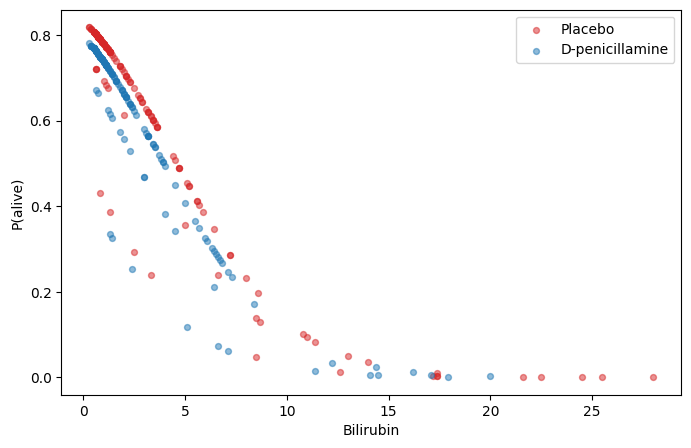

Average change in P(alive) from drug: -0.04255615867830181


In [26]:
probs = logit.predict_proba(X)[:, 1]   # P(alive)

plt.figure(figsize=(8, 5))
for v, c, lbl in [(0, 'tab:red', 'Placebo'), (1, 'tab:blue', 'D-penicillamine')]:
    mask = X['drug_pen'] == v
    plt.scatter(X.loc[mask, 'Bilirubin'], probs[mask], alpha=0.5, s=18, c=c, label=lbl)
plt.xlabel('Bilirubin'); plt.ylabel('P(alive)')
plt.legend(); plt.show()

# Average drug effect via counterfactual
X0, X1 = X.copy(), X.copy()
X0['drug_pen'] = 0
X1['drug_pen'] = 1
diff = logit.predict_proba(X1)[:, 1] - logit.predict_proba(X0)[:, 1]
print('Average change in P(alive) from drug:', diff.mean())

# Comparing D-penicillamine vs the placebo difference was around 0.04,
# so taking this drug lowers predicted survival by around 4.2 percentage points relative to the placebo
# there's really no range where it shows that the drug improves survival

In [27]:
preds = logit.predict(X)
print(confusion_matrix(y, preds))
print('Accuracy:', accuracy_score(y, preds))

[[ 59  66]
 [ 16 171]]
Accuracy: 0.7371794871794872


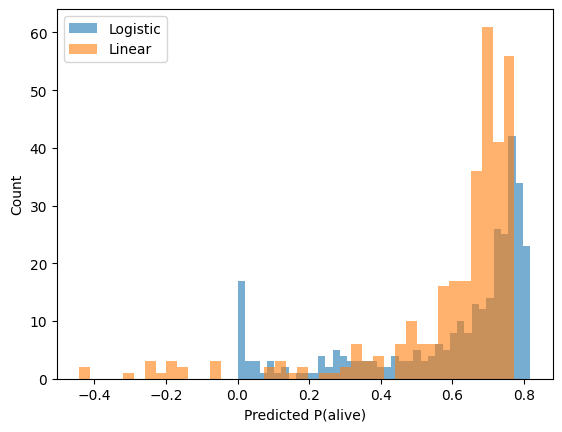

LPM min/max: -0.44173966839359835 0.7738680250928713


In [28]:
lpm = LinearRegression().fit(X, y)
lpm_probs = lpm.predict(X)

plt.hist(probs, bins=40, alpha=0.6, label='Logistic')
plt.hist(lpm_probs, bins=40, alpha=0.6, label='Linear')
plt.xlabel('Predicted P(alive)'); plt.ylabel('Count')
plt.legend(); plt.show()

print('LPM min/max:', lpm_probs.min(), lpm_probs.max())

# the linear model is good but a logistic regression may work better since it keeps predictions between 0 and 1
# as compared to -0.4417 to 0.7739 -- negative probability isn't meaningful here

In [30]:
X3 = df[['edema_S', 'edema_Y', 'Bilirubin']]
y3 = df['Stage'].astype(int)

mlogit = LogisticRegression(multi_class='multinomial', max_iter=1000).fit(X3, y3)

hard = mlogit.predict(X3)
print('Classes:', mlogit.classes_)
print(confusion_matrix(y3, hard, labels=mlogit.classes_))
print('Accuracy:', accuracy_score(y3, hard))

soft = mlogit.predict_proba(X3)
print('Unique hard predictions:', np.unique(hard))
print(pd.DataFrame(soft, columns=mlogit.classes_).describe())

# accuracy of the table was 0.4327. The multinomial logistic regression gives all positve %s for the 4 stages
# but under the hard classification it only predicts stages 3 & 4. Hard classifier doesn't predict every class

Classes: [1 2 3 4]
[[  0   0  16   0]
 [  0   0  63   4]
 [  0   0 105  15]
 [  0   0  79  30]]
Accuracy: 0.4326923076923077
Unique hard predictions: [3 4]
                  1           2           3           4
count  3.120000e+02  312.000000  312.000000  312.000000
mean   5.125179e-02    0.214685    0.384666    0.349397
std    3.555501e-02    0.060985    0.061358    0.133680
min    2.982598e-09    0.012899    0.104528    0.255662
25%    1.802610e-02    0.192306    0.386861    0.270305
50%    5.444797e-02    0.246846    0.395635    0.292649
75%    8.488615e-02    0.253397    0.412623    0.373223
max    1.100461e-01    0.255032    0.428496    0.882573


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?

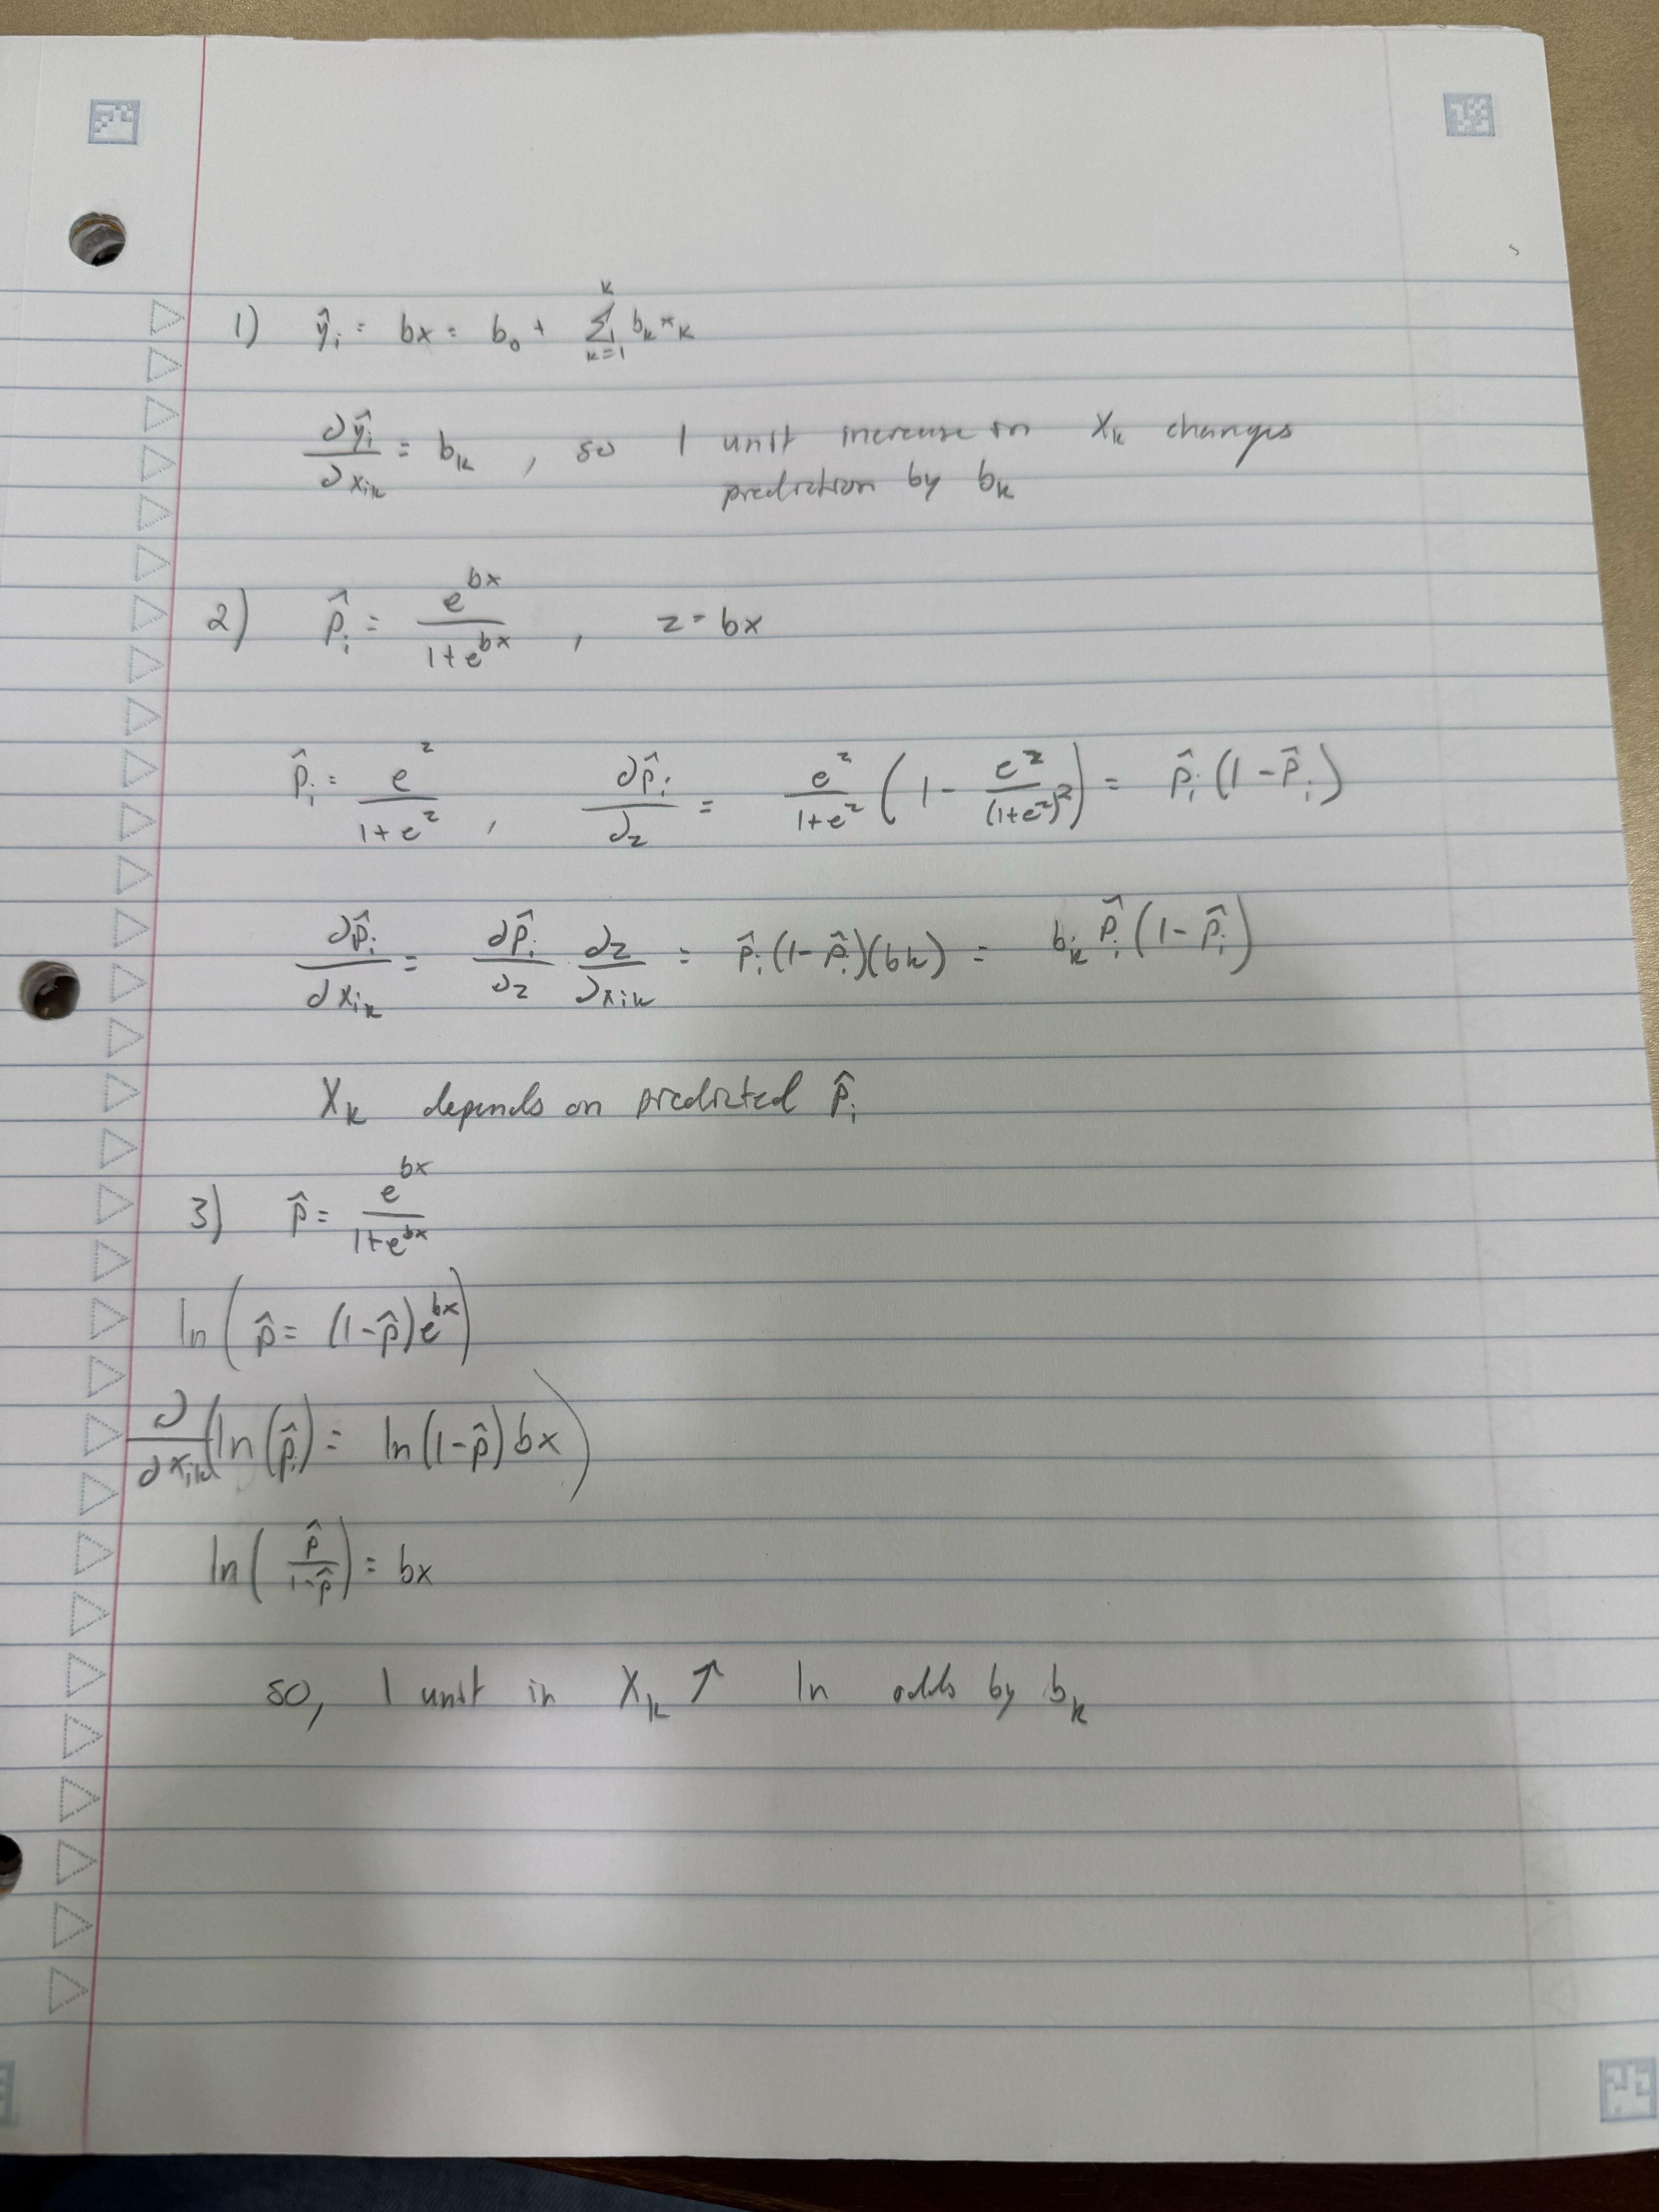